In [ ]:
!nvidia-smi
!pip -q install -U transformers datasets accelerate scikit-learn matplotlib huggingface_hub sentencepiece emoji
!pip -q install --no-cache-dir --force-reinstall "pandas==2.2.2" "numpy==1.26.4"

import os
import gc
import time
import platform
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from IPython.display import display

SEED = 42
N_EVAL = 600
BATCH_SIZE = 32
MAX_LENGTH = 128

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else -1

# Configuración del experimento

CONFIG = {
    "seed": 42,
    "n_eval": 600,
    "batch_size": 32,
    "max_length": 128,
    "latency_repeats": 3,
    "bootstrap_rounds": 300,
    "max_model_retries": 2,
    "use_fp16_if_gpu": True
}

SEED = CONFIG["seed"]
N_EVAL = CONFIG["n_eval"]
BATCH_SIZE = CONFIG["batch_size"]
MAX_LENGTH = CONFIG["max_length"]

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 0 if torch.cuda.is_available() else -1

print("Configuración del experimento:")
display(pd.DataFrame([CONFIG]))

print("Dispositivo:", "GPU" if torch.cuda.is_available() else "CPU")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DO_LOGIN = False

if DO_LOGIN:
    from huggingface_hub import notebook_login
    notebook_login()
else:
    print("Login omitido")


Mon Jun 15 07:20:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

,seed,n_eval,batch_size,max_length,latency_repeats,bootstrap_rounds,max_model_retries,use_fp16_if_gpu
0,42,600,32,128,3,300,2,True


Dispositivo: GPU
GPU: Tesla T4
Login omitido


In [ ]:

# Carga del dataset

from datasets import load_dataset
from collections import Counter

DATASET_ID = "cardiffnlp/tweet_eval"
DATASET_CONFIG = "sentiment"

def cargar_dataset_con_reintentos(dataset_id, dataset_config, intentos=3):
    ultimo_error = None

    for intento in range(1, intentos + 1):
        try:
            print(f"Intento {intento}/{intentos} cargando dataset...")
            ds = load_dataset(dataset_id, dataset_config)
            print("Dataset cargado correctamente.")
            return ds
        except Exception as e:
            ultimo_error = e
            print(f"Error en intento {intento}: {e}")
            time.sleep(3)

    raise RuntimeError(f"No se pudo cargar el dataset. Último error: {ultimo_error}")


def crear_muestra_balanceada(split_dataset, n_total=None, seed=42):


    df = split_dataset.to_pandas()[["text", "label"]].copy()

    if n_total is None:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    clases = sorted(df["label"].unique())
    n_clases = len(clases)
    n_por_clase = max(1, n_total // n_clases)

    partes = []

    for clase in clases:
        df_clase = df[df["label"] == clase]
        n_muestra = min(n_por_clase, len(df_clase))

        partes.append(
            df_clase.sample(n=n_muestra, random_state=seed)
        )

    df_final = pd.concat(partes)
    df_final = df_final.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df_final


dataset = cargar_dataset_con_reintentos(DATASET_ID, DATASET_CONFIG)

print(dataset)

label_names = dataset["test"].features["label"].names
print("Etiquetas:", label_names)

df_eval = crear_muestra_balanceada(
    dataset["test"],
    n_total=N_EVAL,
    seed=SEED
)

texts = df_eval["text"].tolist()
y_true = df_eval["label"].to_numpy()

print("Cantidad de ejemplos evaluados:", len(texts))
print("Distribución de clases:")

conteo_clases = pd.DataFrame({
    "label_id": list(Counter(y_true).keys()),
    "cantidad": list(Counter(y_true).values())
})

conteo_clases["clase"] = conteo_clases["label_id"].apply(lambda x: label_names[x])
display(conteo_clases.sort_values("label_id"))

muestra = pd.DataFrame({
    "texto": texts[:10],
    "label_id": y_true[:10],
    "label": [label_names[i] for i in y_true[:10]]
})

display(muestra)

Intento 1/3 cargando dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset cargado correctamente.
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Etiquetas: ['negative', 'neutral', 'positive']
Cantidad de ejemplos evaluados: 600
Distribución de clases:


,label_id,cantidad,clase
0,0,200,negative
2,1,200,neutral
1,2,200,positive


,texto,label_id,label
0,@user Tony Romo is not worth a pick lower than...,0,negative
1,"Label scan for Bob Dylan's 12th biggest hit, S...",2,positive
2,@user buy Persona 5. Pre-order it on Amazon,2,positive
3,"Although some vaccines protect our children, t...",0,negative
4,@user although it'd be extra nice is Maduro (p...,0,negative
5,louisa wall (mp)- a queer woc- supports cannab...,1,neutral
6,Bad hombres. Raul about to shoot innocent man,0,negative
7,Christmas Charity Benefit 🌲 #MannequinChalleng...,2,positive
8,Join me in ridding your house of #methane prod...,0,negative
9,@user Check on some of the FB swap sites. Ther...,1,neutral


In [ ]:
# Modelos preentrenados seleccionados


MODELOS = [
    {
        "alias": "RoBERTa Twitter",
        "hf_id": "cardiffnlp/twitter-roberta-base-sentiment-latest",
        "justificacion": "Modelo especializado en análisis de sentimiento en tweets."
    },
    {
        "alias": "BERTweet Sentiment",
        "hf_id": "finiteautomata/bertweet-base-sentiment-analysis",
        "justificacion": "Modelo basado en BERTweet, diseñado para lenguaje de Twitter."
    },
    {
        "alias": "XLM-RoBERTa Twitter",
        "hf_id": "cardiffnlp/twitter-xlm-roberta-base-sentiment",
        "justificacion": "Modelo multilingüe para análisis de sentimiento en redes sociales."
    }
]

display(pd.DataFrame(MODELOS))

,alias,hf_id,justificacion
0,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,Modelo especializado en análisis de sentimient...
1,BERTweet Sentiment,finiteautomata/bertweet-base-sentiment-analysis,"Modelo basado en BERTweet, diseñado para lengu..."
2,XLM-RoBERTa Twitter,cardiffnlp/twitter-xlm-roberta-base-sentiment,Modelo multilingüe para análisis de sentimient...


In [ ]:

# Funciones auxiliares

from sklearn.metrics import f1_score

def normalizar_etiqueta(raw_label):
    """
    0 = negative
    1 = neutral
    2 = positive
    """

    s = str(raw_label).strip().lower()
    s = s.replace("__label__", "")
    s = s.replace("-", "_")
    s = s.replace(" ", "_")

    mapa = {
        "negative": 0,
        "neg": 0,
        "label_0": 0,
        "0": 0,

        "neutral": 1,
        "neu": 1,
        "label_1": 1,
        "1": 1,

        "positive": 2,
        "pos": 2,
        "label_2": 2,
        "2": 2,
    }

    if s not in mapa:
        raise ValueError(f"Etiqueta no reconocida por el normalizador: {raw_label}")

    return mapa[s]


def cargar_pipeline_modelo(hf_id):
    model_kwargs = {}
    if torch.cuda.is_available() and CONFIG["use_fp16_if_gpu"]:
        model_kwargs["torch_dtype"] = torch.float16

    tokenizer = AutoTokenizer.from_pretrained(hf_id)
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_id,
        **model_kwargs
    )

    clf = pipeline(
        task="text-classification",
        model=model,
        tokenizer=tokenizer,
        device=DEVICE
    )

    return clf, model, tokenizer


def cargar_pipeline_con_reintentos(hf_id, intentos=2):
    ultimo_error = None

    for intento in range(1, intentos + 1):
        try:
            print(f"Intento {intento}/{intentos} cargando modelo: {hf_id}")
            return cargar_pipeline_modelo(hf_id)

        except Exception as e:
            ultimo_error = e
            print(f"Error cargando modelo en intento {intento}: {e}")
            time.sleep(5)

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    raise RuntimeError(f"No se pudo cargar el modelo {hf_id}. Último error: {ultimo_error}")


def predecir_en_lotes(clf, textos):
    salidas = clf(
        textos,
        batch_size=BATCH_SIZE,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    )

    preds = []
    scores = []
    raw_labels = []

    for salida in salidas:
        if isinstance(salida, list):
            salida = max(salida, key=lambda x: x["score"])

        raw_label = salida["label"]
        pred = normalizar_etiqueta(raw_label)

        preds.append(pred)
        scores.append(float(salida["score"]))
        raw_labels.append(raw_label)

    preds = np.array(preds)

    if len(preds) != len(textos):
        raise ValueError("La cantidad de predicciones no coincide con la cantidad de textos.")

    return preds, scores, raw_labels


def calcular_intervalo_confianza_f1(y_true, y_pred, n_bootstrap=300, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    valores = []

    for _ in range(n_bootstrap):
        indices = rng.integers(0, n, n)

        f1 = f1_score(
            y_true[indices],
            y_pred[indices],
            average="macro",
            zero_division=0
        )

        valores.append(f1)

    limite_inferior = np.percentile(valores, 2.5)
    limite_superior = np.percentile(valores, 97.5)

    return limite_inferior, limite_superior


def evaluar_modelo(model_info):
    alias = model_info["alias"]
    hf_id = model_info["hf_id"]

    print("=" * 90)
    print(f"Evaluando modelo: {alias}")
    print(f"HF ID: {hf_id}")

    clf, model, tokenizer = cargar_pipeline_con_reintentos(
        hf_id,
        intentos=CONFIG["max_model_retries"]
    )

    print("Mapa id2label del modelo:", model.config.id2label)

    # Warm-up
    _ = clf(
        texts[:min(16, len(texts))],
        batch_size=min(16, BATCH_SIZE),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    tiempos = []
    y_pred_final = None

    for repeticion in range(CONFIG["latency_repeats"]):
        print(f"Medición de latencia {repeticion + 1}/{CONFIG['latency_repeats']}")

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        inicio = time.perf_counter()

        y_pred, scores, raw_labels = predecir_en_lotes(clf, texts)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        tiempo_total = time.perf_counter() - inicio
        tiempos.append(tiempo_total)

        if y_pred_final is None:
            y_pred_final = y_pred

    tiempos = np.array(tiempos)

    accuracy = accuracy_score(y_true, y_pred_final)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred_final,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred_final,
        average="weighted",
        zero_division=0
    )

    f1_ci_low, f1_ci_high = calcular_intervalo_confianza_f1(
        y_true,
        y_pred_final,
        n_bootstrap=CONFIG["bootstrap_rounds"],
        seed=SEED
    )

    parametros_millones = sum(p.numel() for p in model.parameters()) / 1_000_000

    tiempo_mediano = float(np.median(tiempos))
    tiempo_promedio = float(np.mean(tiempos))
    tiempo_std = float(np.std(tiempos))

    resultado = {
        "status": "OK",
        "modelo": alias,
        "hf_id": hf_id,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_macro_ci_low": f1_ci_low,
        "f1_macro_ci_high": f1_ci_high,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "tiempo_total_seg_mediano": tiempo_mediano,
        "tiempo_total_seg_promedio": tiempo_promedio,
        "tiempo_total_seg_std": tiempo_std,
        "latencia_ms_por_texto": (tiempo_mediano / len(texts)) * 1000,
        "throughput_textos_por_seg": len(texts) / tiempo_mediano,
        "parametros_millones": parametros_millones,
        "n_ejemplos": len(texts),
        "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "device": "GPU" if torch.cuda.is_available() else "CPU"
    }

    reporte = classification_report(
        y_true,
        y_pred_final,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )

    del clf
    del model
    del tokenizer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return resultado, y_pred_final, reporte

In [ ]:

# Evaluación de los modelos

resultados = []
predicciones = {}
reportes = {}
errores = []

for modelo in MODELOS:
    try:
        resultado, y_pred, reporte = evaluar_modelo(modelo)

        resultados.append(resultado)
        predicciones[modelo["alias"]] = y_pred
        reportes[modelo["alias"]] = reporte

    except Exception as e:
        error_info = {
            "status": "ERROR",
            "modelo": modelo["alias"],
            "hf_id": modelo["hf_id"],
            "error": str(e)
        }

        resultados.append(error_info)
        errores.append(error_info)

        print("=" * 90)
        print(f"Error evaluando {modelo['alias']}")
        print(e)

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

resultados_df = pd.DataFrame(resultados)

resultados_ok = resultados_df[resultados_df["status"] == "OK"].copy()
resultados_error = resultados_df[resultados_df["status"] == "ERROR"].copy()

columnas_metricas = [
    "modelo",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_macro_ci_low",
    "f1_macro_ci_high",
    "latencia_ms_por_texto",
    "throughput_textos_por_seg",
    "parametros_millones",
    "n_ejemplos",
    "device"
]

if len(resultados_ok) > 0:
    display(
        resultados_ok[columnas_metricas]
        .sort_values("f1_macro", ascending=False)
        .round(4)
    )
else:
    print("No hubo modelos evaluados correctamente.")

if len(resultados_error) > 0:
    print("Modelos con error:")
    display(resultados_error)

Evaluando modelo: RoBERTa Twitter
HF ID: cardiffnlp/twitter-roberta-base-sentiment-latest
Intento 1/2 cargando modelo: cardiffnlp/twitter-roberta-base-sentiment-latest


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mapa id2label del modelo: {0: 'negative', 1: 'neutral', 2: 'positive'}
Medición de latencia 1/3
Medición de latencia 2/3
Medición de latencia 3/3
Evaluando modelo: BERTweet Sentiment
HF ID: finiteautomata/bertweet-base-sentiment-analysis
Intento 1/2 cargando modelo: finiteautomata/bertweet-base-sentiment-analysis


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Mapa id2label del modelo: {0: 'NEG', 1: 'NEU', 2: 'POS'}
Medición de latencia 1/3
Medición de latencia 2/3
Medición de latencia 3/3
Evaluando modelo: XLM-RoBERTa Twitter
HF ID: cardiffnlp/twitter-xlm-roberta-base-sentiment
Intento 1/2 cargando modelo: cardiffnlp/twitter-xlm-roberta-base-sentiment


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Mapa id2label del modelo: {0: 'negative', 1: 'neutral', 2: 'positive'}
Medición de latencia 1/3
Medición de latencia 2/3
Medición de latencia 3/3


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_ci_low,f1_macro_ci_high,latencia_ms_por_texto,throughput_textos_por_seg,parametros_millones,n_ejemplos,device
0,RoBERTa Twitter,0.7383,0.7478,0.7383,0.7407,0.7074,0.7723,2.0110,497.2567,124.6479,600,GPU
1,BERTweet Sentiment,0.7067,0.7229,0.7067,0.7108,0.6741,0.7431,1.3881,720.4279,134.9023,600,GPU
2,XLM-RoBERTa Twitter,0.7017,0.7033,0.7017,0.6977,0.6632,0.7363,2.2896,436.7544,278.0460,600,GPU


In [ ]:

# Visualizaciones

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

os.makedirs("figuras_resultados", exist_ok=True)

# Estilo general de gráficas
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

def guardar_figura(nombre):
    ruta = f"figuras_resultados/{nombre}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"Figura guardada: {ruta}")


# Tabla resumen con formato visual

columnas_resumen = [
    "modelo",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "latencia_ms_por_texto",
    "throughput_textos_por_seg",
    "parametros_millones"
]

tabla_resumen = resultados_ok[columnas_resumen].copy()

tabla_resumen = tabla_resumen.rename(columns={
    "modelo": "Modelo",
    "accuracy": "Accuracy",
    "precision_macro": "Precision macro",
    "recall_macro": "Recall macro",
    "f1_macro": "F1 macro",
    "latencia_ms_por_texto": "Latencia ms/texto",
    "throughput_textos_por_seg": "Textos/segundo",
    "parametros_millones": "Parámetros M"
})

tabla_resumen = tabla_resumen.sort_values("F1 macro", ascending=False)

display(
    tabla_resumen.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision macro": "{:.4f}",
        "Recall macro": "{:.4f}",
        "F1 macro": "{:.4f}",
        "Latencia ms/texto": "{:.2f}",
        "Textos/segundo": "{:.2f}",
        "Parámetros M": "{:.1f}"
    })
    .highlight_max(subset=["Accuracy", "Precision macro", "Recall macro", "F1 macro", "Textos/segundo"], color="#C8E6C9")
    .highlight_min(subset=["Latencia ms/texto"], color="#C8E6C9")
    .set_caption("Resumen comparativo de modelos")
)

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,Latencia ms/texto,Textos/segundo,Parámetros M
0,RoBERTa Twitter,0.7383,0.7478,0.7383,0.7407,2.01,497.26,124.6
1,BERTweet Sentiment,0.7067,0.7229,0.7067,0.7108,1.39,720.43,134.9
2,XLM-RoBERTa Twitter,0.7017,0.7033,0.7017,0.6977,2.29,436.75,278.0


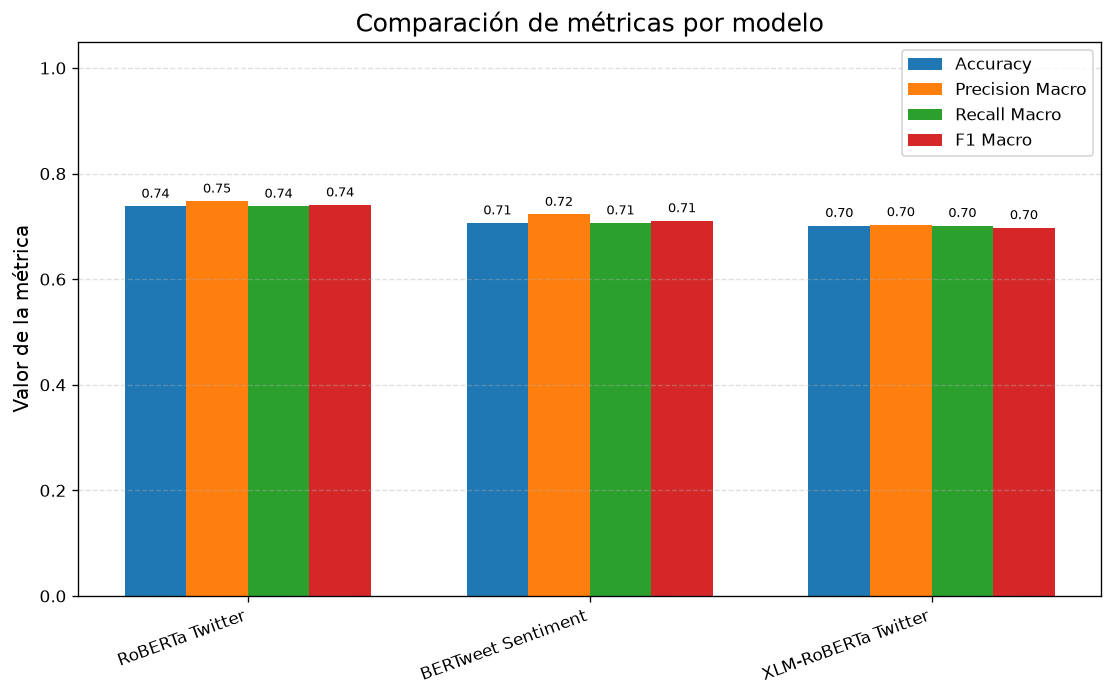

Figura guardada: figuras_resultados/comparacion_metricas_modelos.png


<Figure size 1080x600 with 0 Axes>

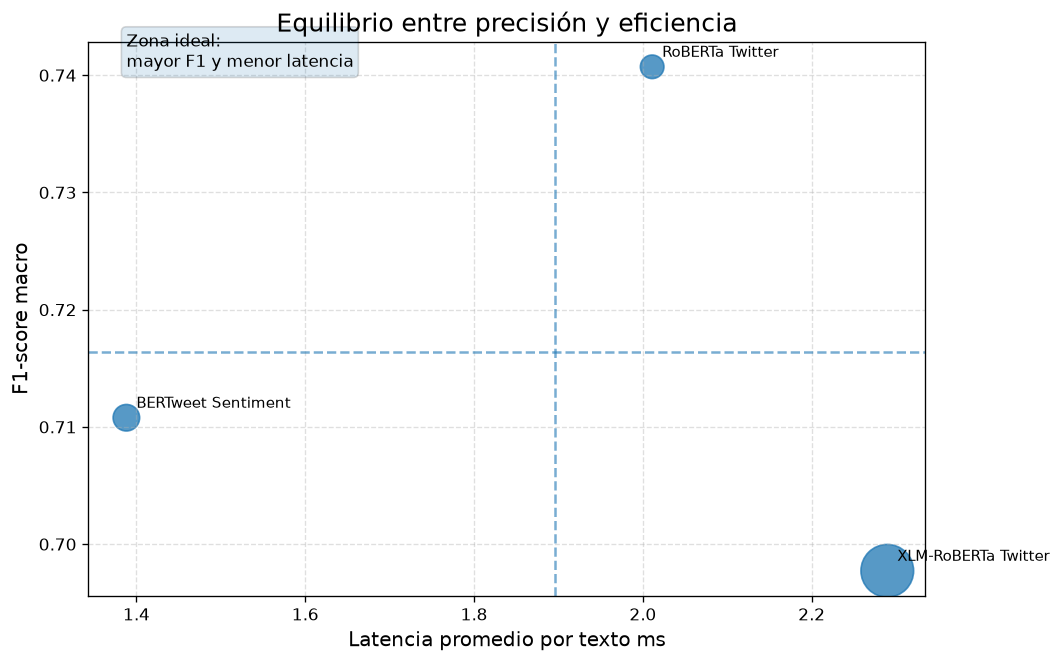

Figura guardada: figuras_resultados/f1_vs_latencia.png


<Figure size 1080x600 with 0 Axes>

In [ ]:

# Comparación de métricas principales

df_plot = resultados_ok.sort_values("f1_macro", ascending=False).copy()

metricas = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro"
]

n_modelos = len(df_plot)
x = np.arange(n_modelos)
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))

for i, metrica in enumerate(metricas):
    valores = df_plot[metrica].values
    posiciones = x + (i - 1.5) * width

    barras = ax.bar(
        posiciones,
        valores,
        width,
        label=metrica.replace("_", " ").title()
    )

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f"{altura:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_title("Comparación de métricas por modelo")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["modelo"], rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()
guardar_figura("comparacion_metricas_modelos")


# F1-score vs Latencia

df_balance = resultados_ok.copy()

fig, ax = plt.subplots(figsize=(9, 6))

# Tamaño del punto según cantidad de parámetros
sizes = df_balance["parametros_millones"]

if sizes.max() != sizes.min():
    sizes_norm = 200 + 800 * (sizes - sizes.min()) / (sizes.max() - sizes.min())
else:
    sizes_norm = np.repeat(500, len(sizes))

scatter = ax.scatter(
    df_balance["latencia_ms_por_texto"],
    df_balance["f1_macro"],
    s=sizes_norm,
    alpha=0.75
)

for _, row in df_balance.iterrows():
    ax.annotate(
        row["modelo"],
        (
            row["latencia_ms_por_texto"],
            row["f1_macro"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

media_f1 = df_balance["f1_macro"].mean()
media_latencia = df_balance["latencia_ms_por_texto"].mean()

ax.axhline(media_f1, linestyle="--", alpha=0.6)
ax.axvline(media_latencia, linestyle="--", alpha=0.6)

ax.text(
    df_balance["latencia_ms_por_texto"].min(),
    df_balance["f1_macro"].max(),
    "Zona ideal:\nmayor F1 y menor latencia",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

ax.set_title("Equilibrio entre precisión y eficiencia")
ax.set_xlabel("Latencia promedio por texto ms")
ax.set_ylabel("F1-score macro")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()
guardar_figura("f1_vs_latencia")

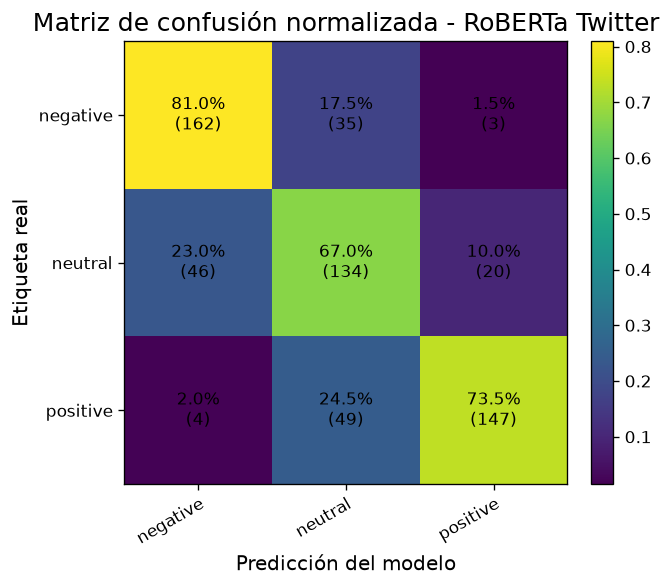

Figura guardada: figuras_resultados/matriz_confusion_roberta_twitter.png


<Figure size 1080x600 with 0 Axes>

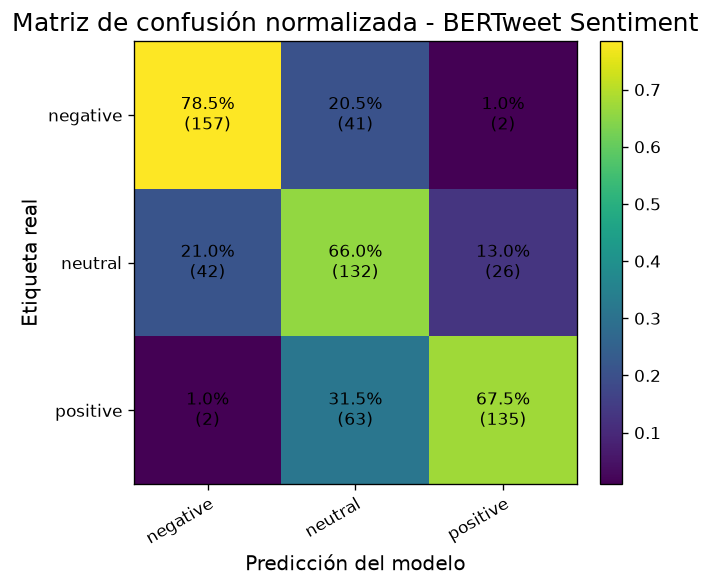

Figura guardada: figuras_resultados/matriz_confusion_bertweet_sentiment.png


<Figure size 1080x600 with 0 Axes>

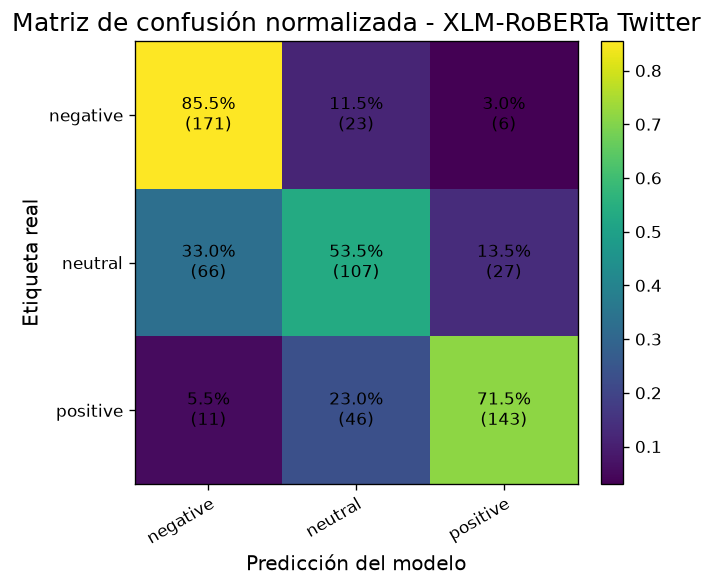

Figura guardada: figuras_resultados/matriz_confusion_xlm-roberta_twitter.png


<Figure size 1080x600 with 0 Axes>

In [ ]:

#  Matrices de confusión normalizadas

for alias, y_pred in predicciones.items():

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    cm_norm = np.divide(
        cm,
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    imagen = ax.imshow(cm_norm, interpolation="nearest")

    ax.set_title(f"Matriz de confusión normalizada - {alias}")
    ax.set_xlabel("Predicción del modelo")
    ax.set_ylabel("Etiqueta real")

    ax.set_xticks(np.arange(len(label_names)))
    ax.set_yticks(np.arange(len(label_names)))
    ax.set_xticklabels(label_names)
    ax.set_yticklabels(label_names)

    plt.setp(
        ax.get_xticklabels(),
        rotation=30,
        ha="right",
        rotation_mode="anchor"
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texto = f"{cm_norm[i, j] * 100:.1f}%\n({cm[i, j]})"
            ax.text(
                j,
                i,
                texto,
                ha="center",
                va="center",
                fontsize=10
            )

    fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    nombre_archivo = alias.lower().replace(" ", "_").replace("/", "_")
    guardar_figura(f"matriz_confusion_{nombre_archivo}")

,Modelo,Clase,Precision,Recall,F1-score,Soporte
0,RoBERTa Twitter,negative,0.7642,0.8100,0.7864,200
3,BERTweet Sentiment,negative,0.7811,0.7850,0.7830,200
6,XLM-RoBERTa Twitter,negative,0.6895,0.8550,0.7634,200
1,RoBERTa Twitter,neutral,0.6147,0.6700,0.6411,200
4,BERTweet Sentiment,neutral,0.5593,0.6600,0.6055,200
7,XLM-RoBERTa Twitter,neutral,0.6080,0.5350,0.5691,200
2,RoBERTa Twitter,positive,0.8647,0.7350,0.7946,200
8,XLM-RoBERTa Twitter,positive,0.8125,0.7150,0.7606,200
5,BERTweet Sentiment,positive,0.8282,0.6750,0.7438,200


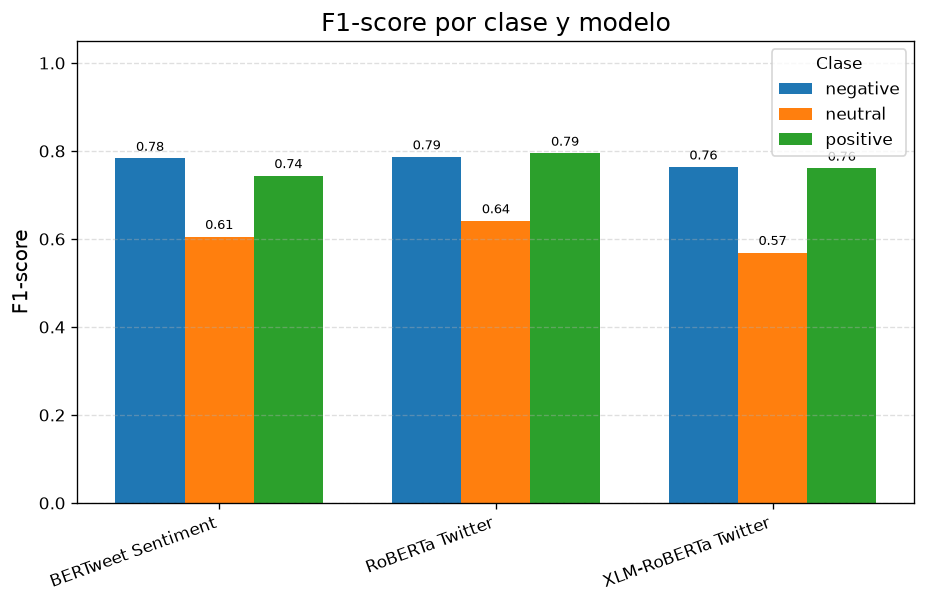

Figura guardada: figuras_resultados/f1_score_por_clase.png


<Figure size 1080x600 with 0 Axes>

In [ ]:
# 10.5 Comparación de F1-score por clase

filas_clase = []

for alias, reporte in reportes.items():
    for clase in label_names:
        filas_clase.append({
            "Modelo": alias,
            "Clase": clase,
            "Precision": reporte[clase]["precision"],
            "Recall": reporte[clase]["recall"],
            "F1-score": reporte[clase]["f1-score"],
            "Soporte": reporte[clase]["support"]
        })

metricas_clase_df = pd.DataFrame(filas_clase)

display(
    metricas_clase_df
    .sort_values(["Clase", "F1-score"], ascending=[True, False])
    .style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "Soporte": "{:.0f}"
    })
    .highlight_max(subset=["Precision", "Recall", "F1-score"], color="#C8E6C9")
    .set_caption("Desempeño por clase")
)

pivot_f1 = metricas_clase_df.pivot(
    index="Modelo",
    columns="Clase",
    values="F1-score"
)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(pivot_f1.index))
width = 0.25

for i, clase in enumerate(pivot_f1.columns):
    valores = pivot_f1[clase].values

    barras = ax.bar(
        x + (i - 1) * width,
        valores,
        width,
        label=clase
    )

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f"{altura:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_title("F1-score por clase y modelo")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(pivot_f1.index, rotation=20, ha="right")
ax.legend(title="Clase")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()
guardar_figura("f1_score_por_clase")

In [ ]:
# Conclusiones parciales automáticas

def generar_conclusiones(df):
    if df.empty:
        print("No hay resultados válidos para generar conclusiones.")
        return

    mejor_f1 = df.sort_values("f1_macro", ascending=False).iloc[0]
    mejor_accuracy = df.sort_values("accuracy", ascending=False).iloc[0]
    mejor_latencia = df.sort_values("latencia_ms_por_texto", ascending=True).iloc[0]

    df_balance = df.copy()
    df_balance["ranking_balance"] = (
        df_balance["f1_macro"].rank(ascending=False)
        + df_balance["latencia_ms_por_texto"].rank(ascending=True)
    )

    mejor_balance = df_balance.sort_values("ranking_balance").iloc[0]

    print("CONCLUSIONES PARCIALES")
    print("=" * 80)

    print(
        f"1. El modelo con mejor F1-score macro fue '{mejor_f1['modelo']}', "
        f"con F1 = {mejor_f1['f1_macro']:.4f}."
    )

    print(
        f"2. El modelo con mejor accuracy fue '{mejor_accuracy['modelo']}', "
        f"con accuracy = {mejor_accuracy['accuracy']:.4f}."
    )

    print(
        f"3. El modelo más eficiente en latencia fue '{mejor_latencia['modelo']}', "
        f"con {mejor_latencia['latencia_ms_por_texto']:.2f} ms por texto."
    )

    print(
        f"4. Considerando equilibrio entre F1-score y latencia, "
        f"el modelo más balanceado fue '{mejor_balance['modelo']}'."
    )

    print(
        "5. Para un contexto donde la precisión sea más importante que el tiempo "
        "de respuesta, conviene elegir el modelo con mayor F1-score."
    )

    print(
        "6. Para un contexto de producción con muchas solicitudes por segundo, "
        "conviene considerar el modelo con menor latencia y mayor throughput."
    )

    print(
        "7. Los resultados dependen de las condiciones de ejecución: tipo de GPU, "
        "tamaño del lote, número de ejemplos evaluados y longitud máxima del texto."
    )

generar_conclusiones(resultados_ok)

CONCLUSIONES PARCIALES
1. El modelo con mejor F1-score macro fue 'RoBERTa Twitter', con F1 = 0.7407.
2. El modelo con mejor accuracy fue 'RoBERTa Twitter', con accuracy = 0.7383.
3. El modelo más eficiente en latencia fue 'BERTweet Sentiment', con 1.39 ms por texto.
4. Considerando equilibrio entre F1-score y latencia, el modelo más balanceado fue 'RoBERTa Twitter'.
5. Para un contexto donde la precisión sea más importante que el tiempo de respuesta, conviene elegir el modelo con mayor F1-score.
6. Para un contexto de producción con muchas solicitudes por segundo, conviene considerar el modelo con menor latencia y mayor throughput.
7. Los resultados dependen de las condiciones de ejecución: tipo de GPU, tamaño del lote, número de ejemplos evaluados y longitud máxima del texto.


In [ ]:
# Guardar resultados completos

import json
import os
from datetime import datetime

os.makedirs("resultados_experimento", exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

ruta_resultados = f"resultados_experimento/comparacion_modelos_{timestamp}.csv"
ruta_errores = f"resultados_experimento/errores_modelos_{timestamp}.csv"
ruta_config = f"resultados_experimento/configuracion_experimento_{timestamp}.json"

resultados_df.to_csv(ruta_resultados, index=False)

if len(resultados_error) > 0:
    resultados_error.to_csv(ruta_errores, index=False)

metadata = {
    "timestamp": timestamp,
    "dataset_id": DATASET_ID,
    "dataset_config": DATASET_CONFIG,
    "label_names": label_names,
    "config": CONFIG,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "modelos": MODELOS
}

with open(ruta_config, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Archivos guardados:")
print(ruta_resultados)
print(ruta_config)

if len(resultados_error) > 0:
    print(ruta_errores)

try:
    from google.colab import files
    files.download(ruta_resultados)
    files.download(ruta_config)

    if len(resultados_error) > 0:
        files.download(ruta_errores)

except Exception:
    print("Descarga automática disponible únicamente en Google Colab.")

Archivos guardados:
resultados_experimento/comparacion_modelos_20260615_072211.csv
resultados_experimento/configuracion_experimento_20260615_072211.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dispositivo: GPU
GPU: Tesla T4
Mejor modelo seleccionado automáticamente
Modelo: RoBERTa Twitter
HF ID: cardiffnlp/twitter-roberta-base-sentiment-latest
F1 macro: 0.7407
Textos usados en la prueba manual:


,texto,esperado_aproximado
0,"I love this product, it works perfectly!",positive
1,This is the worst experience I have ever had.,negative
2,"The service was okay, nothing special.",neutral
3,The app is useful but sometimes it crashes.,neutral
4,I waited for two hours and nobody helped me.,negative
5,"Amazing quality, fast delivery and great support.",positive
6,"The update is not bad, but I expected more imp...",neutral
7,I do not recommend this service to anyone.,negative
8,"It is fine, but there are better options.",neutral
9,Absolutely fantastic experience from start to ...,positive


Cargando mejor modelo para prueba manual...
RoBERTa Twitter


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluando manualmente: XLM-RoBERTa Twitter
HF ID: cardiffnlp/twitter-xlm-roberta-base-sentiment


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,modelo,hf_id,texto,esperado_aproximado,prediccion,coincide,confianza,latencia_ms
0,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,"I love this product, it works perfectly!",positive,positive,True,0.9881,17.83
1,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,This is the worst experience I have ever had.,negative,negative,True,0.9511,18.67
2,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,"The service was okay, nothing special.",neutral,neutral,True,0.5130,16.99
3,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,The app is useful but sometimes it crashes.,neutral,negative,False,0.7449,16.07
4,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,I waited for two hours and nobody helped me.,negative,negative,True,0.9341,18.78
5,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,"Amazing quality, fast delivery and great support.",positive,positive,True,0.9730,17.20
6,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,"The update is not bad, but I expected more improvements.",neutral,positive,False,0.8162,19.02
7,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,I do not recommend this service to anyone.,negative,negative,True,0.9127,17.41
8,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,"It is fine, but there are better options.",neutral,neutral,True,0.6141,19.60
9,RoBERTa Twitter,cardiffnlp/twitter-roberta-base-sentiment-latest,Absolutely fantastic experience from start to finish.,positive,positive,True,0.9839,17.45


,modelo,coincidencia_manual,confianza_promedio,latencia_promedio_ms
1,RoBERTa Twitter,0.8000,0.8431,17.90
0,BERTweet Sentiment,0.7000,0.9044,13.30
2,XLM-RoBERTa Twitter,0.6000,0.7688,10.92


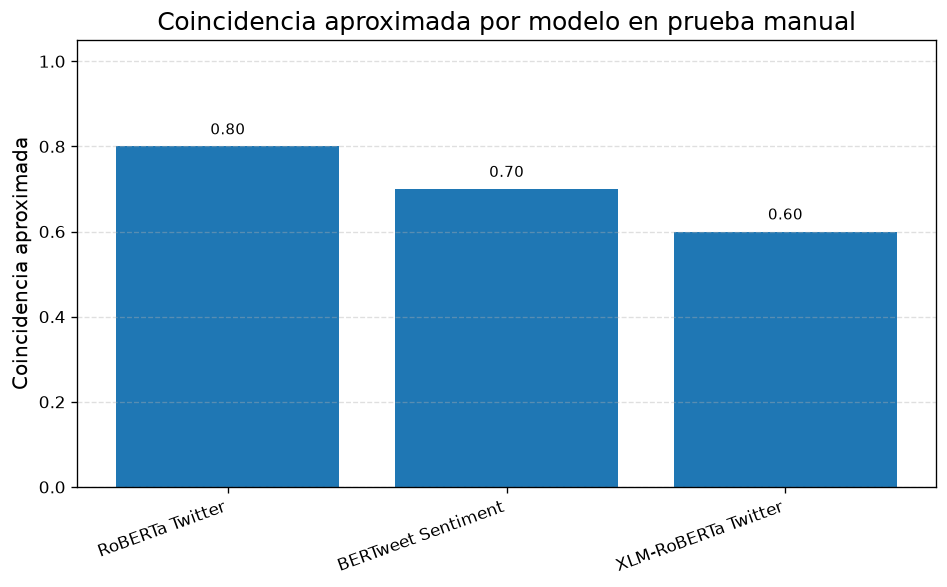

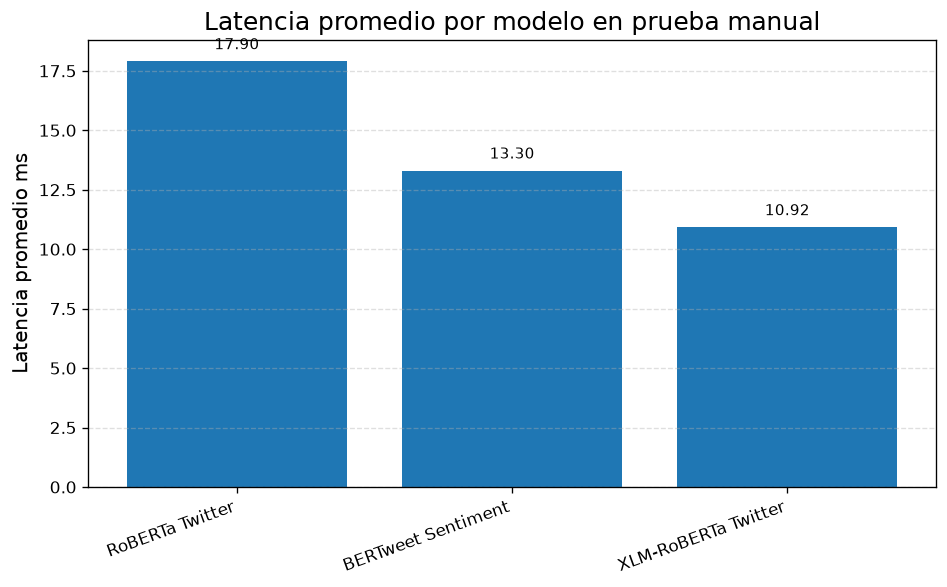

CONCLUSIONES DE LA PRUEBA FINAL
1. En la prueba manual, el modelo con mayor coincidencia aproximada fue 'RoBERTa Twitter', con una coincidencia de 0.8000.
2. El modelo más rápido en la prueba manual fue 'XLM-RoBERTa Twitter', con una latencia promedio de 10.92 ms por texto.
3. La coincidencia manual debe interpretarse como una evaluación cualitativa, porque las etiquetas esperadas fueron asignadas manualmente como referencia aproximada.
4. Esta prueba complementa la evaluación cuantitativa del dataset, ya que permite observar el comportamiento de los modelos ante textos nuevos, ambiguos o realistas.
Archivos guardados en la carpeta: resultados_prueba_final
Prueba interactiva con el mejor modelo


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Escribe un texto en inglés para analizar sentimiento: Hola mundo
Resultado interactivo
Texto: Hola mundo
Modelo: RoBERTa Twitter
Predicción: neutral
Confianza: 0.6373
Probabilidad negativa: 0.123
Probabilidad neutral: 0.6373
Probabilidad positiva: 0.2397
Latencia ms: 11.44


,texto,modelo,prediccion,confianza,prob_negative,prob_neutral,prob_positive,latencia_ms
0,Hola mundo,RoBERTa Twitter,neutral,0.6373,0.1230,0.6373,0.2397,11.44


In [ ]:
# PRUEBA FINAL

import os
import gc
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import pipeline
from IPython.display import display

ACTIVAR_PRUEBA_INTERACTIVA = True

os.makedirs("resultados_prueba_final", exist_ok=True)

if "DEVICE" not in globals():
    DEVICE = 0 if torch.cuda.is_available() else -1

if "MAX_LENGTH" not in globals():
    MAX_LENGTH = 128

if "label_names" not in globals():
    label_names = ["negative", "neutral", "positive"]

if "resultados_ok" not in globals() or len(resultados_ok) == 0:
    raise ValueError("No hay modelos evaluados correctamente.")

if "MODELOS" not in globals():
    MODELOS = [
        {
            "alias": row["modelo"],
            "hf_id": row["hf_id"],
            "justificacion": "Modelo recuperado desde resultados_ok."
        }
        for _, row in resultados_ok[["modelo", "hf_id"]].drop_duplicates().iterrows()
    ]

print("Dispositivo:", "GPU" if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Selección automática del mejor modelo


mejor_fila = resultados_ok.sort_values("f1_macro", ascending=False).iloc[0]

mejor_modelo_nombre = mejor_fila["modelo"]
mejor_modelo_id = mejor_fila["hf_id"]

print("=" * 80)
print("Mejor modelo seleccionado automáticamente")
print("Modelo:", mejor_modelo_nombre)
print("HF ID:", mejor_modelo_id)
print("F1 macro:", round(mejor_fila["f1_macro"], 4))
print("=" * 80)

# Textos de prueba manual

textos_prueba = [
    "I love this product, it works perfectly!",
    "This is the worst experience I have ever had.",
    "The service was okay, nothing special.",
    "The app is useful but sometimes it crashes.",
    "I waited for two hours and nobody helped me.",
    "Amazing quality, fast delivery and great support.",
    "The update is not bad, but I expected more improvements.",
    "I do not recommend this service to anyone.",
    "It is fine, but there are better options.",
    "Absolutely fantastic experience from start to finish."
]

# Etiquetas esperadas aproximadas:
# 0 = negative
# 1 = neutral
# 2 = positive

etiquetas_esperadas = [
    "positive",
    "negative",
    "neutral",
    "neutral",
    "negative",
    "positive",
    "neutral",
    "negative",
    "neutral",
    "positive"
]

df_textos_prueba = pd.DataFrame({
    "texto": textos_prueba,
    "esperado_aproximado": etiquetas_esperadas
})

print("Textos usados en la prueba manual:")
display(df_textos_prueba)

# Funciones auxiliares para la prueba final

def normalizar_etiqueta_final(raw_label):
    s = str(raw_label).strip().lower()
    s = s.replace("__label__", "")
    s = s.replace("-", "_")
    s = s.replace(" ", "_")

    mapa = {
        "negative": 0,
        "neg": 0,
        "label_0": 0,
        "0": 0,

        "neutral": 1,
        "neu": 1,
        "label_1": 1,
        "1": 1,

        "positive": 2,
        "pos": 2,
        "label_2": 2,
        "2": 2,
    }

    if s not in mapa:
        raise ValueError(f"Etiqueta no reconocida: {raw_label}")

    return mapa[s]


def etiqueta_normalizada_texto(raw_label):
    pred_id = normalizar_etiqueta_final(raw_label)
    return label_names[pred_id]


def cargar_clasificador(hf_id):
    clf = pipeline(
        task="text-classification",
        model=hf_id,
        tokenizer=hf_id,
        device=DEVICE
    )

    return clf


def obtener_scores_texto(clf, texto):
    try:
        salida = clf(
            texto,
            truncation=True,
            max_length=MAX_LENGTH,
            top_k=None
        )
    except TypeError:
        salida = clf(
            texto,
            truncation=True,
            max_length=MAX_LENGTH,
            return_all_scores=True
        )

    if isinstance(salida, list) and len(salida) > 0 and isinstance(salida[0], list):
        salida = salida[0]

    if isinstance(salida, dict):
        salida = [salida]

    scores = {
        "negative": 0.0,
        "neutral": 0.0,
        "positive": 0.0
    }

    for item in salida:
        etiqueta = etiqueta_normalizada_texto(item["label"])
        scores[etiqueta] = float(item["score"])

    prediccion = max(scores, key=scores.get)
    confianza = scores[prediccion]

    return prediccion, confianza, scores


def evaluar_textos_manuales(clf, textos, esperadas=None):
    filas = []

    for i, texto in enumerate(textos):

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        inicio = time.perf_counter()

        prediccion, confianza, scores = obtener_scores_texto(clf, texto)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        latencia_ms = (time.perf_counter() - inicio) * 1000

        esperado = esperadas[i] if esperadas is not None else None

        coincide = None
        if esperado is not None:
            coincide = prediccion == esperado

        filas.append({
            "texto": texto,
            "esperado_aproximado": esperado,
            "prediccion": prediccion,
            "coincide": coincide,
            "confianza": confianza,
            "prob_negative": scores["negative"],
            "prob_neutral": scores["neutral"],
            "prob_positive": scores["positive"],
            "latencia_ms": latencia_ms
        })

    return pd.DataFrame(filas)


def resaltar_probabilidad_mayor(row):
    columnas_prob = ["prob_negative", "prob_neutral", "prob_positive"]

    estilos = [""] * len(row)

    if all(col in row.index for col in columnas_prob):
        max_col = row[columnas_prob].astype(float).idxmax()

        for i, col in enumerate(row.index):
            if col == max_col:
                estilos[i] = "background-color: #C8E6C9"

    return estilos

print("=" * 80)
print("Cargando mejor modelo para prueba manual...")
print(mejor_modelo_nombre)
print("=" * 80)

clf_final = cargar_clasificador(mejor_modelo_id)

df_resultado_manual = evaluar_textos_manuales(
    clf_final,
    textos_prueba,
    etiquetas_esperadas
)

display(
    df_resultado_manual.style
    .format({
        "confianza": "{:.4f}",
        "prob_negative": "{:.4f}",
        "prob_neutral": "{:.4f}",
        "prob_positive": "{:.4f}",
        "latencia_ms": "{:.2f}"
    })
    .apply(resaltar_probabilidad_mayor, axis=1)
    .set_caption(f"Prueba manual con el mejor modelo: {mejor_modelo_nombre}")
)

accuracy_manual = df_resultado_manual["coincide"].mean()
latencia_promedio_manual = df_resultado_manual["latencia_ms"].mean()
confianza_promedio_manual = df_resultado_manual["confianza"].mean()

print("Resumen de prueba manual con el mejor modelo")
print("=" * 80)
print("Modelo:", mejor_modelo_nombre)
print("Textos evaluados:", len(df_resultado_manual))
print("Coincidencia aproximada:", round(accuracy_manual, 4))
print("Latencia promedio ms:", round(latencia_promedio_manual, 2))
print("Confianza promedio:", round(confianza_promedio_manual, 4))

df_resultado_manual.to_csv(
    "resultados_prueba_final/prueba_manual_mejor_modelo.csv",
    index=False
)

# Liberar memoria antes de comparar todos los modelos
del clf_final
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Comparación manual entre los tres modelos

resultados_manuales_modelos = []

for modelo in MODELOS:
    alias = modelo["alias"]
    hf_id = modelo["hf_id"]

    print("=" * 80)
    print("Evaluando manualmente:", alias)
    print("HF ID:", hf_id)

    try:
        clf_temp = cargar_clasificador(hf_id)

        df_temp = evaluar_textos_manuales(
            clf_temp,
            textos_prueba,
            etiquetas_esperadas
        )

        for _, row in df_temp.iterrows():
            resultados_manuales_modelos.append({
                "modelo": alias,
                "hf_id": hf_id,
                "texto": row["texto"],
                "esperado_aproximado": row["esperado_aproximado"],
                "prediccion": row["prediccion"],
                "coincide": row["coincide"],
                "confianza": row["confianza"],
                "latencia_ms": row["latencia_ms"]
            })

        del clf_temp
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error evaluando {alias}: {e}")

df_comparacion_manual = pd.DataFrame(resultados_manuales_modelos)

if len(df_comparacion_manual) == 0:
    raise ValueError("No se pudo generar la comparación manual entre modelos.")

display(
    df_comparacion_manual.style
    .format({
        "confianza": "{:.4f}",
        "latencia_ms": "{:.2f}"
    })
    .set_caption("Comparación manual entre modelos")
)

df_comparacion_manual.to_csv(
    "resultados_prueba_final/comparacion_manual_modelos.csv",
    index=False
)

# Resumen de comparación manual por modelo

resumen_manual_modelos = (
    df_comparacion_manual
    .groupby("modelo")
    .agg(
        coincidencia_manual=("coincide", "mean"),
        confianza_promedio=("confianza", "mean"),
        latencia_promedio_ms=("latencia_ms", "mean")
    )
    .reset_index()
    .sort_values("coincidencia_manual", ascending=False)
)

display(
    resumen_manual_modelos.style
    .format({
        "coincidencia_manual": "{:.4f}",
        "confianza_promedio": "{:.4f}",
        "latencia_promedio_ms": "{:.2f}"
    })
    .highlight_max(
        subset=["coincidencia_manual", "confianza_promedio"],
        color="#C8E6C9"
    )
    .highlight_min(
        subset=["latencia_promedio_ms"],
        color="#C8E6C9"
    )
    .set_caption("Resumen de prueba manual por modelo")
)

resumen_manual_modelos.to_csv(
    "resultados_prueba_final/resumen_prueba_manual_modelos.csv",
    index=False
)

# Visualizaciones de la prueba final

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(resumen_manual_modelos))

ax.bar(
    x,
    resumen_manual_modelos["coincidencia_manual"]
)

ax.set_title("Coincidencia aproximada por modelo en prueba manual")
ax.set_ylabel("Coincidencia aproximada")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(resumen_manual_modelos["modelo"], rotation=20, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for i, valor in enumerate(resumen_manual_modelos["coincidencia_manual"]):
    ax.text(
        i,
        valor + 0.02,
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "resultados_prueba_final/grafica_coincidencia_manual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x,
    resumen_manual_modelos["latencia_promedio_ms"]
)

ax.set_title("Latencia promedio por modelo en prueba manual")
ax.set_ylabel("Latencia promedio ms")
ax.set_xticks(x)
ax.set_xticklabels(resumen_manual_modelos["modelo"], rotation=20, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for i, valor in enumerate(resumen_manual_modelos["latencia_promedio_ms"]):
    ax.text(
        i,
        valor + max(resumen_manual_modelos["latencia_promedio_ms"]) * 0.02,
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "resultados_prueba_final/grafica_latencia_manual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Conclusiones automáticas de la prueba final

mejor_manual = resumen_manual_modelos.sort_values(
    ["coincidencia_manual", "confianza_promedio"],
    ascending=[False, False]
).iloc[0]

mas_rapido_manual = resumen_manual_modelos.sort_values(
    "latencia_promedio_ms",
    ascending=True
).iloc[0]

print("=" * 80)
print("CONCLUSIONES DE LA PRUEBA FINAL")
print("=" * 80)

print(
    f"1. En la prueba manual, el modelo con mayor coincidencia aproximada fue "
    f"'{mejor_manual['modelo']}', con una coincidencia de "
    f"{mejor_manual['coincidencia_manual']:.4f}."
)

print(
    f"2. El modelo más rápido en la prueba manual fue "
    f"'{mas_rapido_manual['modelo']}', con una latencia promedio de "
    f"{mas_rapido_manual['latencia_promedio_ms']:.2f} ms por texto."
)

print(
    "3. La coincidencia manual debe interpretarse como una evaluación cualitativa, "
    "porque las etiquetas esperadas fueron asignadas manualmente como referencia aproximada."
)

print(
    "4. Esta prueba complementa la evaluación cuantitativa del dataset, ya que permite "
    "observar el comportamiento de los modelos ante textos nuevos, ambiguos o realistas."
)

print("=" * 80)
print("Archivos guardados en la carpeta: resultados_prueba_final")
print("=" * 80)

# Prueba interactiva

if ACTIVAR_PRUEBA_INTERACTIVA:

    print("=" * 80)
    print("Prueba interactiva con el mejor modelo")
    print("=" * 80)

    clf_interactivo = cargar_clasificador(mejor_modelo_id)

    texto_usuario = input("Escribe un texto en inglés para analizar sentimiento: ")

    if texto_usuario.strip() != "":
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        inicio = time.perf_counter()

        prediccion, confianza, scores = obtener_scores_texto(
            clf_interactivo,
            texto_usuario
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        latencia_ms = (time.perf_counter() - inicio) * 1000

        print("=" * 80)
        print("Resultado interactivo")
        print("=" * 80)
        print("Texto:", texto_usuario)
        print("Modelo:", mejor_modelo_nombre)
        print("Predicción:", prediccion)
        print("Confianza:", round(confianza, 4))
        print("Probabilidad negativa:", round(scores["negative"], 4))
        print("Probabilidad neutral:", round(scores["neutral"], 4))
        print("Probabilidad positiva:", round(scores["positive"], 4))
        print("Latencia ms:", round(latencia_ms, 2))

        df_interactivo = pd.DataFrame([{
            "texto": texto_usuario,
            "modelo": mejor_modelo_nombre,
            "prediccion": prediccion,
            "confianza": confianza,
            "prob_negative": scores["negative"],
            "prob_neutral": scores["neutral"],
            "prob_positive": scores["positive"],
            "latencia_ms": latencia_ms
        }])

        display(
            df_interactivo.style
            .format({
                "confianza": "{:.4f}",
                "prob_negative": "{:.4f}",
                "prob_neutral": "{:.4f}",
                "prob_positive": "{:.4f}",
                "latencia_ms": "{:.2f}"
            })
            .apply(resaltar_probabilidad_mayor, axis=1)
            .set_caption("Resultado de prueba interactiva")
        )

        df_interactivo.to_csv(
            "resultados_prueba_final/prueba_interactiva.csv",
            index=False
        )

    else:
        print("No se ingresó texto. Se omite la prueba interactiva.")

    del clf_interactivo
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()